# Phase 3 -- Triple Fusion (Image + Text + Clinical Metadata)
## PneumoFusionNet | MIMIC-CXR PA | Three-Modality Fusion

### Architecture Overview
Extends Phase 2v2 (AUC=0.949) by adding a **third modality: clinical metadata**

**Three modalities:**
1. **Image** → DenseNet-121 + CBAM (frozen from Phase 1.1v4 Fold 2) → 1024-d
2. **Text**  → Bio_ClinicalBERT (last 2 layers unfrozen) → 768-d tokens → Cross-Attention → 512-d
3. **Clinical** → MLP (16 features → 128 → 64-d)

**Fusion:** Concat [img(1024) + cross_attn(512) + meta(64)] = 1600-d → MLP classifier

### Clinical Features (16 total)
- Demographics: age, gender_M, is_deceased
- Vitals: heart_rate, respiratory_rate, spo2, systolic_bp, diastolic_bp, temperature_f
- Labs: wbc, hemoglobin, hematocrit, creatinine, crp, alk_phos, albumin

### Strategy: Load Phase 2v2 weights, add & train metadata branch
The image encoder, text encoder, and cross-attention fusion weights are
loaded from `best_v2_model.pth`. Only the new MetadataEncoder and
updated classifier head are trained from scratch.

In [1]:
# --- CELL 0: Imports & Reproducibility ---
import os, random, warnings, json, copy, re
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import cv2
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from transformers import AutoTokenizer, AutoModel
import torchxrayvision as xrv

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, accuracy_score, f1_score
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device : cuda
PyTorch: 2.5.1+cu121


In [2]:
# --- CELL 1: Configuration & Paths ---
BASE_DIR      = r'c:\\2026\\PneumoFusionNet\\mimic\\1000_dataset'

# Input data
TEXT_CSV      = os.path.join(BASE_DIR, 'phase2_reports_no_impression.csv')
CLINICAL_CSV  = os.path.join(BASE_DIR, 'phase3_clinical_data.csv')
BBOX_CSV      = os.path.join(BASE_DIR, 'outputs', 'Phase_1.1v2_PA_enhanced', 'lung_bboxes.csv')

# Checkpoints
P1_CKPT       = os.path.join(BASE_DIR, 'outputs', 'Phase_1.1v4_PA_crossval', 'best_model_fold2.pth')
P2V2_CKPT     = os.path.join(BASE_DIR, 'outputs', 'Phase_2v2_improved', 'best_v2_model.pth')

# Output
SAVE_DIR      = os.path.join(BASE_DIR, 'outputs', 'Phase_3_triple_fusion')
os.makedirs(SAVE_DIR, exist_ok=True)

# Model hyperparams
IMG_SIZE       = 224
MAX_TEXT_LEN   = 256
CLINBERT_MODEL = 'emilyalsentzer/Bio_ClinicalBERT'
IMG_FEAT_DIM   = 1024
TXT_FEAT_DIM   = 768
ATTN_DIM       = 512
ATTN_HEADS     = 8
META_HIDDEN    = 128   # metadata MLP hidden dim
META_OUT_DIM   = 64    # metadata MLP output dim
N_CLINICAL_FEATURES = 16

# Training
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
BATCH_SIZE  = 16
LR_FUSION   = 2e-4   # fusion head + metadata encoder
LR_BERT     = 1e-5   # unfrozen BERT layers
LR_META     = 1e-3   # metadata MLP (higher LR for small network)
EPOCHS      = 40
PATIENCE    = 8
FOCAL_GAMMA = 2.0
MIXUP_ALPHA = 0.2
CLASSES     = ['NORMAL', 'PNEUMONIA']
MEAN = [0.5020]; STD = [0.2703]

# Clinical feature columns to use
CLINICAL_FEATURES = [
    'age', 'gender_M', 'is_deceased',
    'heart_rate', 'respiratory_rate', 'spo2', 'systolic_bp', 'diastolic_bp', 'temperature_f',
    'wbc', 'hemoglobin', 'hematocrit', 'creatinine', 'crp', 'alk_phos', 'albumin'
]

print(f'Text CSV       : {os.path.exists(TEXT_CSV)}')
print(f'Clinical CSV   : {os.path.exists(CLINICAL_CSV)}')
print(f'P1 checkpoint  : {os.path.exists(P1_CKPT)}')
print(f'P2v2 checkpoint: {os.path.exists(P2V2_CKPT)}')
print(f'Save dir       : {SAVE_DIR}')
print(f'Clinical feats : {N_CLINICAL_FEATURES}')

Text CSV       : True
Clinical CSV   : True
P1 checkpoint  : True
P2v2 checkpoint: True
Save dir       : c:\\2026\\PneumoFusionNet\\mimic\\1000_dataset\outputs\Phase_3_triple_fusion
Clinical feats : 16


In [3]:
# --- CELL 2: Data Loading & Merging ---

def resolve_path(p):
    if pd.isna(p) or str(p).strip() == '': return ''
    p = str(p).replace('/', os.sep).replace('\\\\', os.sep)
    return p if os.path.isabs(p) else os.path.join(BASE_DIR, p)

# Load text/image CSV (same as Phase 2v2 - 1989 PA samples)
text_df = pd.read_csv(TEXT_CSV)
text_df['image_path']   = text_df['image_path'].apply(resolve_path)
text_df['report_path']  = text_df['report_path'].apply(resolve_path)
text_df['report_clean'] = text_df['report_no_impression'].fillna('').astype(str)

# Load clinical metadata CSV
clinical_df = pd.read_csv(CLINICAL_CSV)
print(f'Text CSV rows     : {len(text_df)}')
print(f'Clinical CSV rows : {len(clinical_df)}')
print(f'Clinical columns  : {list(clinical_df.columns)}')

Text CSV rows     : 1989
Clinical CSV rows : 3221
Clinical columns  : ['subject_id', 'study_id', 'image_path', 'label', 'gender', 'age', 'is_deceased', 'diastolic_bp', 'heart_rate', 'respiratory_rate', 'spo2', 'systolic_bp', 'temperature_c', 'temperature_f', 'albumin', 'alk_phos', 'creatinine', 'crp', 'hematocrit', 'hemoglobin', 'pco2', 'ph', 'po2', 'wbc']


In [4]:
# --- CELL 3: Text Extraction (FINDINGS + HISTORY) ---
# Same approach as Phase 2v2 - Improvement 1

LEAKAGE_RE = re.compile(
    r'\bpneumonia\b|\bpneumonic\b|\bno[ -]acute[ -]\w+|\bno finding\w*'
    r'|\bcompatible with\b|\bconsistent with\b|\bnormal study\b|\bno significant\b',
    re.IGNORECASE
)

def extract_rich_text(text):
    parts = []
    h = re.search(r'HISTORY[:\s]+(.*?)(?=FINDINGS|TECHNIQUE|COMPARISON|\n\n|\Z)',
                  text, re.DOTALL | re.IGNORECASE)
    if h: parts.append(h.group(1).strip())
    f = re.search(r'FINDINGS[:\s]+(.*?)(?=IMPRESSION|CONCLUSION|\n\n|\Z)',
                  text, re.DOTALL | re.IGNORECASE)
    if f: parts.append(f.group(1).strip())
    result = ' '.join(parts).strip()
    if not result: result = text[:512]
    result = LEAKAGE_RE.sub('[REDACTED]', result)
    return result

def read_report(path):
    try:
        with open(path, encoding='utf-8', errors='ignore') as f:
            return f.read().strip()
    except: return ''

has_report = text_df['report_path'].apply(os.path.exists)
print(f'Reports on disk: {has_report.sum()}/{len(text_df)}')

text_df['full_report'] = text_df['report_path'].apply(read_report)
text_df['report_rich'] = text_df['full_report'].apply(extract_rich_text)
print(f'Avg words (rich): {text_df["report_rich"].str.split().str.len().mean():.1f}')

Reports on disk: 1989/1989
Avg words (rich): 50.0


In [5]:
# --- CELL 4: Merge Text + Clinical Data & Preprocess Clinical Features ---

# Create gender_M binary feature from clinical data
if 'gender' in clinical_df.columns:
    clinical_df['gender_M'] = (clinical_df['gender'].str.upper() == 'M').astype(int)

# Merge on study_id
df = text_df.merge(
    clinical_df[['study_id'] + [c for c in CLINICAL_FEATURES if c in clinical_df.columns]],
    on='study_id',
    how='inner'
)

print(f'Rows after merge: {len(df)}')
print(f'Label distribution:')
print(df['label'].value_counts().rename({0: 'Normal', 1: 'Pneumonia'}))

# Check for missing clinical features
missing_features = [c for c in CLINICAL_FEATURES if c not in df.columns]
print(f'\nMissing clinical features: {missing_features}')

# Only keep features that exist
CLINICAL_FEATURES = [c for c in CLINICAL_FEATURES if c in df.columns]
N_CLINICAL_FEATURES = len(CLINICAL_FEATURES)
print(f'Using {N_CLINICAL_FEATURES} clinical features: {CLINICAL_FEATURES}')

# Fill NaN with median for numeric features
for col in CLINICAL_FEATURES:
    if df[col].dtype in [np.float64, np.int64, float, int]:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
    else:
        df[col] = df[col].fillna(0)

print(f'\nMissing values after fill: {df[CLINICAL_FEATURES].isnull().sum().sum()}')

Rows after merge: 2653
Label distribution:
Normal       1465
Pneumonia    1188
Name: label, dtype: int64

Missing clinical features: []
Using 16 clinical features: ['age', 'gender_M', 'is_deceased', 'heart_rate', 'respiratory_rate', 'spo2', 'systolic_bp', 'diastolic_bp', 'temperature_f', 'wbc', 'hemoglobin', 'hematocrit', 'creatinine', 'crp', 'alk_phos', 'albumin']

Missing values after fill: 0


In [6]:
# --- CELL 5: Train / Val / Test Split (70/15/15, stratified) ---
train_val_df, test_df = train_test_split(
    df, test_size=0.15, stratify=df['label'], random_state=SEED)
val_frac = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
train_df, val_df = train_test_split(
    train_val_df, test_size=val_frac, stratify=train_val_df['label'], random_state=SEED)

for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    n0 = (split['label']==0).sum(); n1 = (split['label']==1).sum()
    print(f'{name:5s}: {len(split):5d}  (Normal={n0}, Pneumonia={n1})')

# Fit scaler ONLY on training data to avoid data leakage
scaler = StandardScaler()
train_df = train_df.copy()
val_df   = val_df.copy()
test_df  = test_df.copy()

train_df[CLINICAL_FEATURES] = scaler.fit_transform(train_df[CLINICAL_FEATURES].astype(float))
val_df[CLINICAL_FEATURES]   = scaler.transform(val_df[CLINICAL_FEATURES].astype(float))
test_df[CLINICAL_FEATURES]  = scaler.transform(test_df[CLINICAL_FEATURES].astype(float))
print('\nClinical features standardised (fit on train only). No data leakage.')

Train:  1857  (Normal=1025, Pneumonia=832)
Val  :   398  (Normal=220, Pneumonia=178)
Test :   398  (Normal=220, Pneumonia=178)

Clinical features standardised (fit on train only). No data leakage.


In [7]:
# --- CELL 6: Bbox Lookup & Triple Dataset Class ---
bbox_df     = pd.read_csv(BBOX_CSV)
bbox_lookup = bbox_df.set_index('image_path').to_dict('index')
print(f'Bbox entries: {len(bbox_lookup)}')

class TripleModalCXRDataset(Dataset):
    """Dataset returning (image, text_ids, text_mask, clinical_features, label)"""
    def __init__(self, df, bbox_lookup, tokenizer, img_transform,
                 clinical_features, max_len=MAX_TEXT_LEN):
        self.df               = df.reset_index(drop=True)
        self.bbox_lookup      = bbox_lookup
        self.tokenizer        = tokenizer
        self.transform        = img_transform
        self.clinical_features = clinical_features
        self.max_len          = max_len
        self.clahe            = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # --- IMAGE ---
        img = cv2.imread(row.image_path, cv2.IMREAD_GRAYSCALE)
        if img is None: img = np.zeros((224,224), dtype=np.uint8)
        img = self.clahe.apply(img)
        bb  = self.bbox_lookup.get(row.image_path, None)
        if bb and bb.get('x_max',0)>0:
            img = img[bb['y_min']:bb['y_max'], bb['x_min']:bb['x_max']]
        img = self.transform(Image.fromarray(img))

        # --- TEXT ---
        enc = self.tokenizer(
            row.report_rich, max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )

        # --- CLINICAL METADATA ---
        meta = torch.tensor(
            [float(row[c]) for c in self.clinical_features],
            dtype=torch.float32
        )

        return (
            img,
            enc['input_ids'].squeeze(0),
            enc['attention_mask'].squeeze(0),
            meta,
            int(row.label)
        )

    def set_transform(self, t): self.transform = t

val_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])
train_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])
print('Dataset class ready.')

Bbox entries: 354
Dataset class ready.


In [8]:
# --- CELL 7: Model Architecture ---

# ---- CBAM (same as Phase 1 & 2) ----
class ChannelAttention(nn.Module):
    def __init__(self, c, r=16):
        super().__init__()
        self.avg=nn.AdaptiveAvgPool2d(1); self.max=nn.AdaptiveMaxPool2d(1)
        self.mlp=nn.Sequential(nn.Conv2d(c,c//r,1,bias=False),nn.ReLU(True),nn.Conv2d(c//r,c,1,bias=False))
        self.sig=nn.Sigmoid()
    def forward(self,x): return x*self.sig(self.mlp(self.avg(x))+self.mlp(self.max(x)))

class SpatialAttention(nn.Module):
    def __init__(self,k=7):
        super().__init__()
        self.conv=nn.Conv2d(2,1,k,padding=k//2,bias=False); self.sig=nn.Sigmoid()
    def forward(self,x):
        return x*self.sig(self.conv(torch.cat([x.mean(1,keepdim=True),x.max(1,keepdim=True)[0]],1)))

class CBAM(nn.Module):
    def __init__(self,c,r=16):
        super().__init__()
        self.ca=ChannelAttention(c,r); self.sa=SpatialAttention()
    def forward(self,x): return self.sa(self.ca(x))

# ---- Image Encoder (Phase-1 frozen) -- SAME AS PHASE 2v2 ----
class ImageEncoder(nn.Module):
    def __init__(self, ckpt):
        super().__init__()
        xrv_m=xrv.models.DenseNet(weights='densenet121-res224-all')
        self.features=xrv_m.features; self.cbam=CBAM(1024); self.pool=nn.AdaptiveAvgPool2d(1)
        sd={k:v for k,v in torch.load(ckpt,map_location='cpu').items()
            if k.startswith('features.') or k.startswith('cbam.')}
        miss,unexp=self.load_state_dict(sd,strict=False)
        print(f'[ImageEncoder] loaded {len(sd)} keys | missing={len(miss)} unexpected={len(unexp)}')
        for p in self.parameters(): p.requires_grad=False
    def forward(self,x):
        f=F.relu(self.features(x),True); f=self.cbam(f)
        return self.pool(f).flatten(1)       # (B,1024)
    def get_feature_maps(self,x):
        return F.relu(self.cbam(self.features(x)),True)  # (B,1024,H,W) for Grad-CAM

# ---- Text Encoder: ClinicalBERT (last 2 layers unfrozen) -- SAME AS PHASE 2v2 ----
class TextEncoder(nn.Module):
    def __init__(self, model_name=CLINBERT_MODEL):
        super().__init__()
        self.bert=AutoModel.from_pretrained(model_name)
        for name,p in self.bert.named_parameters():
            if 'encoder.layer.10' in name or 'encoder.layer.11' in name or 'pooler' in name:
                p.requires_grad=True
            else:
                p.requires_grad=False
        trainable=sum(p.numel() for p in self.bert.parameters() if p.requires_grad)
        print(f'[TextEncoder] Unfrozen BERT params: {trainable:,}')
    def forward(self,input_ids,attention_mask):
        out=self.bert(input_ids=input_ids,attention_mask=attention_mask)
        return out.last_hidden_state   # (B, seq_len, 768)

# ---- NEW: Metadata Encoder MLP ----
class MetadataEncoder(nn.Module):
    """Small MLP: 16 clinical features → 128 → 64-d embedding"""
    def __init__(self, in_dim=N_CLINICAL_FEATURES, hidden=META_HIDDEN, out_dim=META_OUT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden, out_dim),
            nn.ReLU()
        )
        trainable = sum(p.numel() for p in self.net.parameters())
        print(f'[MetadataEncoder] Trainable params: {trainable:,}')
    def forward(self, x):
        return self.net(x)  # (B, META_OUT_DIM=64)

# ---- Triple Fusion Net (extends Phase 2v2 CrossAttnFusionNet + metadata) ----
class TripleFusionNet(nn.Module):
    """
    Fuses:
      - img_feat    (B, 1024) from DenseNet+CBAM
      - txt_tokens  (B, seq, 768) from ClinicalBERT
      - meta        (B, 16) clinical metadata

    Cross-Attention: image queries text → (B, 512)
    Triple concat: [img(1024) + cross_attn(512) + meta(64)] = 1600-d
    Classifier: LayerNorm → Dropout → Linear chain → 2 logits
    """
    def __init__(self,
                 img_dim=IMG_FEAT_DIM,
                 txt_dim=TXT_FEAT_DIM,
                 attn_dim=ATTN_DIM,
                 heads=ATTN_HEADS,
                 meta_out=META_OUT_DIM):
        super().__init__()
        # Cross-attention components (same as Phase 2v2)
        self.query_proj = nn.Linear(img_dim, attn_dim)
        self.key_proj   = nn.Linear(txt_dim, attn_dim)
        self.val_proj   = nn.Linear(txt_dim, attn_dim)
        self.cross_attn = nn.MultiheadAttention(attn_dim, heads, batch_first=True, dropout=0.1)
        self.norm1      = nn.LayerNorm(attn_dim)

        # Triple fusion classifier (1024 + 512 + 64 = 1600)
        fused_dim = img_dim + attn_dim + meta_out  # 1600
        self.classifier = nn.Sequential(
            nn.LayerNorm(fused_dim),
            nn.Dropout(0.4),
            nn.Linear(fused_dim, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 2)
        )
        print(f'[TripleFusionNet] fused_dim={fused_dim} (img={img_dim} + attn={attn_dim} + meta={meta_out})')

    def forward(self, img_feat, txt_tokens, meta_feat):
        # img_feat   : (B, 1024)
        # txt_tokens : (B, seq_len, 768)
        # meta_feat  : (B, 64)
        q = self.query_proj(img_feat).unsqueeze(1)   # (B, 1, 512)
        k = self.key_proj(txt_tokens)                 # (B, seq, 512)
        v = self.val_proj(txt_tokens)                 # (B, seq, 512)
        attended, _ = self.cross_attn(q, k, v)        # (B, 1, 512)
        attended = self.norm1(attended.squeeze(1))     # (B, 512)

        fused = torch.cat([img_feat, attended, meta_feat], dim=1)  # (B, 1600)
        return self.classifier(fused)

print('All model classes defined.')

All model classes defined.


In [9]:
# --- CELL 8: Focal Loss & Triple Mixup Utilities ---

class FocalLoss(nn.Module):
    def __init__(self, gamma=FOCAL_GAMMA, weight=None):
        super().__init__()
        self.gamma=gamma; self.weight=weight
    def forward(self, logits, labels):
        ce  = F.cross_entropy(logits, labels, weight=self.weight, reduction='none')
        pt  = torch.exp(-ce)
        loss= ((1-pt)**self.gamma * ce).mean()
        return loss

def mixup_triple(img_feat, txt_tokens, meta_feat, labels, alpha=MIXUP_ALPHA):
    """Mixup on all three embedding branches simultaneously"""
    if alpha <= 0: return img_feat, txt_tokens, meta_feat, labels, labels, 1.0
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(img_feat.size(0), device=img_feat.device)
    img_mix  = lam * img_feat   + (1-lam) * img_feat[idx]
    txt_mix  = lam * txt_tokens + (1-lam) * txt_tokens[idx]
    meta_mix = lam * meta_feat  + (1-lam) * meta_feat[idx]
    return img_mix, txt_mix, meta_mix, labels, labels[idx], lam

def mixup_criterion(criterion, logits, labels_a, labels_b, lam):
    return lam * criterion(logits, labels_a) + (1-lam) * criterion(logits, labels_b)

print('Focal Loss and Triple Mixup ready.')

Focal Loss and Triple Mixup ready.


In [10]:
# --- CELL 9: Instantiate Models, Load Phase 2v2 Weights, Build DataLoaders ---

print('Loading ClinicalBERT tokenizer...')
tokenizer     = AutoTokenizer.from_pretrained(CLINBERT_MODEL)
text_encoder  = TextEncoder(CLINBERT_MODEL).to(DEVICE)

print('Loading Phase-1 Image Encoder (Fold 2)...')
image_encoder = ImageEncoder(P1_CKPT).to(DEVICE)

print('Building MetadataEncoder...')
meta_encoder  = MetadataEncoder(in_dim=N_CLINICAL_FEATURES).to(DEVICE)

print('Building TripleFusionNet...')
fusion_model  = TripleFusionNet().to(DEVICE)

# --- Load Phase 2v2 weights into text_encoder and cross-attn components ---
print(f'\nLoading Phase 2v2 checkpoint: {P2V2_CKPT}')
if os.path.exists(P2V2_CKPT):
    p2v2_state = torch.load(P2V2_CKPT, map_location='cpu')

    # Load BERT weights from Phase 2v2 (text encoder was fine-tuned)
    if 'text' in p2v2_state:
        miss, unexp = text_encoder.load_state_dict(p2v2_state['text'], strict=False)
        print(f'  [TextEncoder] Loaded P2v2 weights | missing={len(miss)} unexpected={len(unexp)}')

    # Load cross-attention + classifier weights from Phase 2v2
    # (query_proj, key_proj, val_proj, cross_attn, norm1 are compatible)
    if 'fusion' in p2v2_state:
        fusion_p2v2 = p2v2_state['fusion']
        # Only load the cross-attention keys (not classifier — it changed from 1536 to 1600)
        ca_keys = {k:v for k,v in fusion_p2v2.items()
                   if any(k.startswith(pfx) for pfx in
                          ['query_proj','key_proj','val_proj','cross_attn','norm1'])}
        miss2, unexp2 = fusion_model.load_state_dict(ca_keys, strict=False)
        print(f'  [FusionNet] Loaded {len(ca_keys)} cross-attn keys from P2v2 | '
              f'missing={len(miss2)} unexpected={len(unexp2)}')
        print(f'  (Classifier head re-initialised: 1536-d → 1600-d for triple fusion)')
else:
    print(f'  WARNING: P2v2 checkpoint not found. Training from scratch!')

trainable_fusion = sum(p.numel() for p in fusion_model.parameters() if p.requires_grad)
trainable_bert   = sum(p.numel() for p in text_encoder.parameters() if p.requires_grad)
trainable_meta   = sum(p.numel() for p in meta_encoder.parameters() if p.requires_grad)
print(f'\nTrainable params:')
print(f'  Fusion Net   : {trainable_fusion:,}')
print(f'  BERT (unfrozen): {trainable_bert:,}')
print(f'  Metadata MLP : {trainable_meta:,}')

# --- DataLoaders ---
train_ds = TripleModalCXRDataset(train_df, bbox_lookup, tokenizer, train_tfm, CLINICAL_FEATURES)
val_ds   = TripleModalCXRDataset(val_df,   bbox_lookup, tokenizer, val_tfm,   CLINICAL_FEATURES)
test_ds  = TripleModalCXRDataset(test_df,  bbox_lookup, tokenizer, val_tfm,   CLINICAL_FEATURES)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print(f'\nTrain batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Loading ClinicalBERT tokenizer...
[TextEncoder] Unfrozen BERT params: 14,766,336
Loading Phase-1 Image Encoder (Fold 2)...
[ImageEncoder] loaded 728 keys | missing=3 unexpected=3
Building MetadataEncoder...
[MetadataEncoder] Trainable params: 26,944
Building TripleFusionNet...
[TripleFusionNet] fused_dim=1600 (img=1024 + attn=512 + meta=64)

Loading Phase 2v2 checkpoint: c:\\2026\\PneumoFusionNet\\mimic\\1000_dataset\outputs\Phase_2v2_improved\best_v2_model.pth
  [TextEncoder] Loaded P2v2 weights | missing=0 unexpected=0
  [FusionNet] Loaded 12 cross-attn keys from P2v2 | missing=8 unexpected=0
  (Classifier head re-initialised: 1536-d → 1600-d for triple fusion)

Trainable params:
  Fusion Net   : 3,252,738
  BERT (unfrozen): 14,766,336
  Metadata MLP : 26,944

Train batches: 117 | Val: 25 | Test: 25


In [11]:
# --- CELL 10: Training Loop ---

def eval_epoch(fusion, img_enc, txt_enc, meta_enc, loader, criterion, device):
    fusion.eval(); img_enc.eval(); txt_enc.eval(); meta_enc.eval()
    total_loss, all_probs, all_labels = 0.0, [], []
    with torch.no_grad():
        for imgs,ids,masks,meta,labels in loader:
            imgs   = imgs.to(device)
            ids    = ids.to(device)
            masks  = masks.to(device)
            meta   = meta.to(device)
            labels = labels.to(device)

            img_f   = img_enc(imgs)            # (B, 1024)
            txt_t   = txt_enc(ids, masks)      # (B, seq, 768)
            meta_f  = meta_enc(meta)           # (B, 64)
            logits  = fusion(img_f, txt_t, meta_f)

            loss  = criterion(logits, labels)
            probs = F.softmax(logits, dim=1)[:,1].cpu().numpy()
            total_loss += loss.item()*labels.size(0)
            all_probs.extend(probs); all_labels.extend(labels.cpu().tolist())

    acc = accuracy_score(all_labels,[1 if p>=0.5 else 0 for p in all_probs])
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels))>1 else 0.5
    return total_loss/len(all_labels), acc, auc, all_probs, all_labels

def find_optimal_threshold(labels, probs):
    fpr,tpr,thresh=roc_curve(labels,probs)
    return float(thresh[np.argmax(tpr-fpr)])

def find_clinical_threshold(labels, probs, target_sens=0.90):
    fpr,tpr,thresh=roc_curve(labels,probs)
    for t,s in zip(thresh, tpr):
        if s >= target_sens:
            return float(t)
    return float(thresh[np.argmax(tpr-fpr)])

# Class weights
n0=(train_df['label']==0).sum(); n1=(train_df['label']==1).sum()
weight=torch.tensor([n1/(n0+n1), n0/(n0+n1)], dtype=torch.float).to(DEVICE)
criterion_focal = FocalLoss(gamma=FOCAL_GAMMA, weight=weight)

# Optimizer with 3 separate learning rates
optimizer = torch.optim.AdamW([
    {'params': text_encoder.parameters(),  'lr': LR_BERT,   'weight_decay': 1e-4},
    {'params': fusion_model.parameters(),  'lr': LR_FUSION, 'weight_decay': 1e-4},
    {'params': meta_encoder.parameters(),  'lr': LR_META,   'weight_decay': 1e-3},
])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_auc, best_state, patience_cnt = 0.0, None, 0
history = {'train_loss':[], 'val_loss':[], 'train_auc':[], 'val_auc':[]}

for epoch in range(1, EPOCHS+1):
    # ---- Train ----
    fusion_model.train(); image_encoder.eval(); text_encoder.train(); meta_encoder.train()
    ep_loss, ep_probs, ep_labels = 0.0, [], []

    for imgs,ids,masks,meta,labels in train_loader:
        imgs   = imgs.to(DEVICE)
        ids    = ids.to(DEVICE)
        masks  = masks.to(DEVICE)
        meta   = meta.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.no_grad():
            img_f = image_encoder(imgs)       # (B, 1024) - frozen
        txt_t  = text_encoder(ids, masks)     # (B, seq, 768) - partially trainable
        meta_f = meta_encoder(meta)           # (B, 64) - trainable

        # Triple Mixup on all embeddings
        img_m, txt_m, meta_m, la, lb, lam = mixup_triple(img_f, txt_t, meta_f, labels)

        optimizer.zero_grad()
        logits = fusion_model(img_m, txt_m, meta_m)
        loss   = mixup_criterion(criterion_focal, logits, la, lb, lam)
        loss.backward()

        all_params = (list(fusion_model.parameters()) +
                      list(text_encoder.parameters()) +
                      list(meta_encoder.parameters()))
        nn.utils.clip_grad_norm_(all_params, 1.0)
        optimizer.step()

        probs = F.softmax(logits.detach(), dim=1)[:,1].cpu().numpy()
        ep_loss += loss.item()*labels.size(0)
        ep_probs.extend(probs); ep_labels.extend(labels.cpu().tolist())

    scheduler.step()
    tr_loss = ep_loss/len(ep_labels)
    tr_auc  = roc_auc_score(ep_labels, ep_probs) if len(set(ep_labels))>1 else 0.5

    # ---- Val ----
    val_loss,val_acc,val_auc,_,_ = eval_epoch(
        fusion_model, image_encoder, text_encoder, meta_encoder,
        val_loader, criterion_focal, DEVICE)

    history['train_loss'].append(tr_loss); history['val_loss'].append(val_loss)
    history['train_auc'].append(tr_auc);   history['val_auc'].append(val_auc)

    marker=''
    if val_auc > best_auc:
        best_auc=val_auc
        best_state=copy.deepcopy({
            'fusion': fusion_model.state_dict(),
            'text':   text_encoder.state_dict(),
            'meta':   meta_encoder.state_dict()
        })
        torch.save(best_state, os.path.join(SAVE_DIR,'best_p3_model.pth'))
        patience_cnt=0; marker=' <-- best'
    else:
        patience_cnt+=1

    if epoch%5==0 or marker:
        print(f'Ep {epoch:03d} | tr_loss={tr_loss:.4f} tr_auc={tr_auc:.4f} '
              f'| val_auc={val_auc:.4f} val_acc={val_acc:.3f}{marker}')
    if patience_cnt>=PATIENCE:
        print(f'Early stop at epoch {epoch}.'); break

print(f'Best Val AUC: {best_auc:.4f}')

Ep 001 | tr_loss=0.0148 tr_auc=0.7598 | val_auc=0.9815 val_acc=0.932 <-- best
Ep 002 | tr_loss=0.0135 tr_auc=0.7559 | val_auc=0.9826 val_acc=0.945 <-- best
Ep 003 | tr_loss=0.0125 tr_auc=0.7472 | val_auc=0.9853 val_acc=0.942 <-- best
Ep 005 | tr_loss=0.0122 tr_auc=0.8156 | val_auc=0.9831 val_acc=0.945
Ep 009 | tr_loss=0.0113 tr_auc=0.7221 | val_auc=0.9868 val_acc=0.950 <-- best
Ep 010 | tr_loss=0.0113 tr_auc=0.8060 | val_auc=0.9856 val_acc=0.955
Ep 015 | tr_loss=0.0085 tr_auc=0.7946 | val_auc=0.9848 val_acc=0.942
Ep 016 | tr_loss=0.0095 tr_auc=0.7992 | val_auc=0.9870 val_acc=0.947 <-- best
Ep 020 | tr_loss=0.0077 tr_auc=0.7711 | val_auc=0.9857 val_acc=0.942
Early stop at epoch 24.
Best Val AUC: 0.9870


In [12]:
# --- CELL 11: Test Set Evaluation ---
fusion_model.load_state_dict(best_state['fusion'])
text_encoder.load_state_dict(best_state['text'])
meta_encoder.load_state_dict(best_state['meta'])

_,test_acc,test_auc,test_probs,test_labels = eval_epoch(
    fusion_model, image_encoder, text_encoder, meta_encoder,
    test_loader, criterion_focal, DEVICE)

thresh_youden   = find_optimal_threshold(test_labels, test_probs)
thresh_clinical = find_clinical_threshold(test_labels, test_probs, target_sens=0.90)

preds_def      = [1 if p>=0.5            else 0 for p in test_probs]
preds_youden   = [1 if p>=thresh_youden  else 0 for p in test_probs]
preds_clinical = [1 if p>=thresh_clinical else 0 for p in test_probs]

def metrics(labels, preds, name, thresh):
    cm = confusion_matrix(labels, preds)
    s  = cm[1,1]/(cm[1,0]+cm[1,1]) if (cm[1,0]+cm[1,1])>0 else 0
    sp = cm[0,0]/(cm[0,0]+cm[0,1]) if (cm[0,0]+cm[0,1])>0 else 0
    ac = (cm[0,0]+cm[1,1])/cm.sum()
    f1 = f1_score(labels, preds)
    print(f'{name} (thresh={thresh:.3f}): Acc={ac:.3f} F1={f1:.3f} Sens={s:.3f} Spec={sp:.3f}')
    return s, sp, ac, f1

print(f'Test AUC: {test_auc:.4f}\n')
s_d,sp_d,ac_d,f1_d     = metrics(test_labels, preds_def,      'Default  ', 0.5)
s_y,sp_y,ac_y,f1_y     = metrics(test_labels, preds_youden,   'Youden-J ', thresh_youden)
s_c,sp_c,ac_c,f1_c     = metrics(test_labels, preds_clinical, 'Clinical ', thresh_clinical)

Test AUC: 0.9841

Default   (thresh=0.500): Acc=0.942 F1=0.934 Sens=0.921 Spec=0.959
Youden-J  (thresh=0.447): Acc=0.947 F1=0.942 Sens=0.949 Spec=0.945
Clinical  (thresh=0.614): Acc=0.940 F1=0.931 Sens=0.904 Spec=0.968


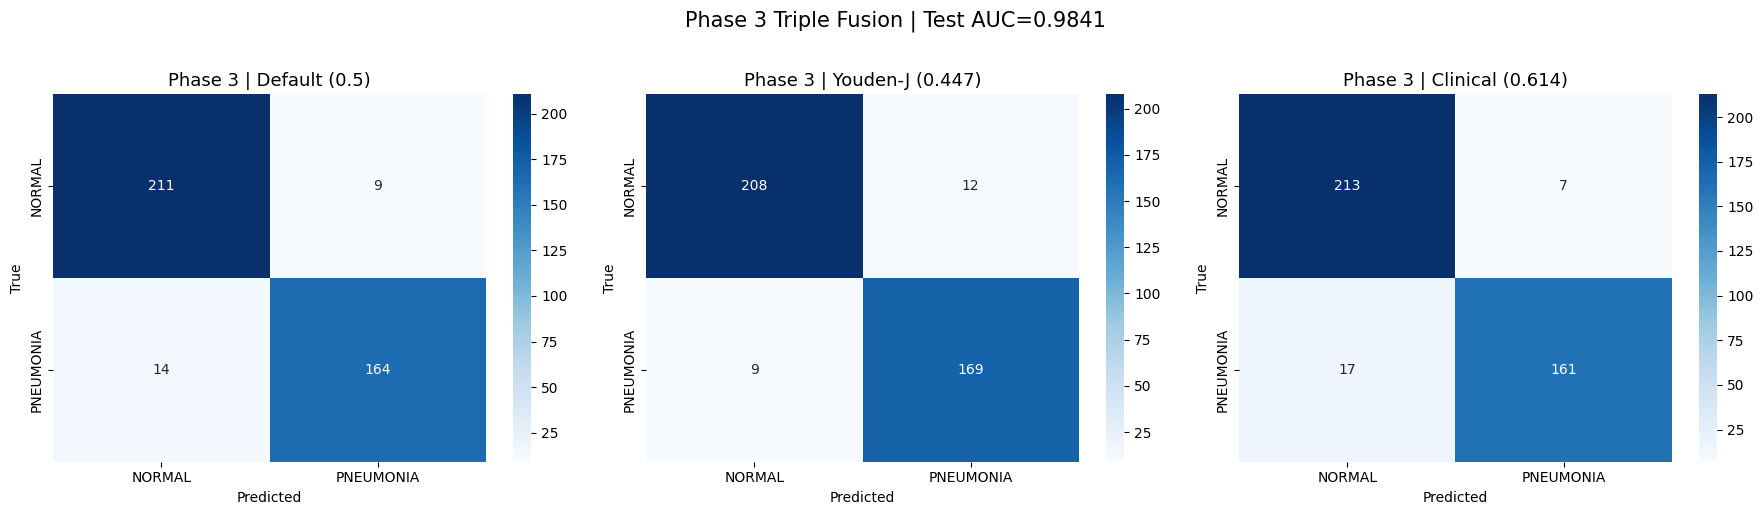

Saved confusion matrices.


In [13]:
# --- CELL 12: Confusion Matrices ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, preds, title in zip(axes,
    [preds_def, preds_youden, preds_clinical],
    ['Default (0.5)', f'Youden-J ({thresh_youden:.3f})', f'Clinical ({thresh_clinical:.3f})']):
    cm_arr = confusion_matrix(test_labels, preds)
    sns.heatmap(cm_arr, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES)
    ax.set_title(f'Phase 3 | {title}', fontsize=13)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.suptitle(f'Phase 3 Triple Fusion | Test AUC={test_auc:.4f}', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'p3_confusion_matrices.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved confusion matrices.')

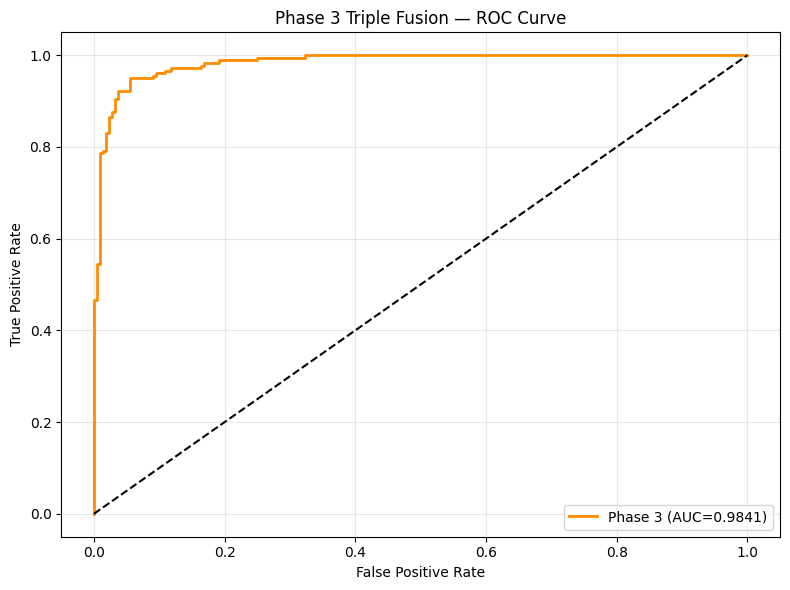

Saved ROC curve.


In [14]:
# --- CELL 13: ROC Curve ---
fpr, tpr, _ = roc_curve(test_labels, test_probs)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, lw=2, color='darkorange', label=f'Phase 3 (AUC={test_auc:.4f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Phase 3 Triple Fusion — ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'p3_roc_curve.png'), dpi=150)
plt.show()
print('Saved ROC curve.')

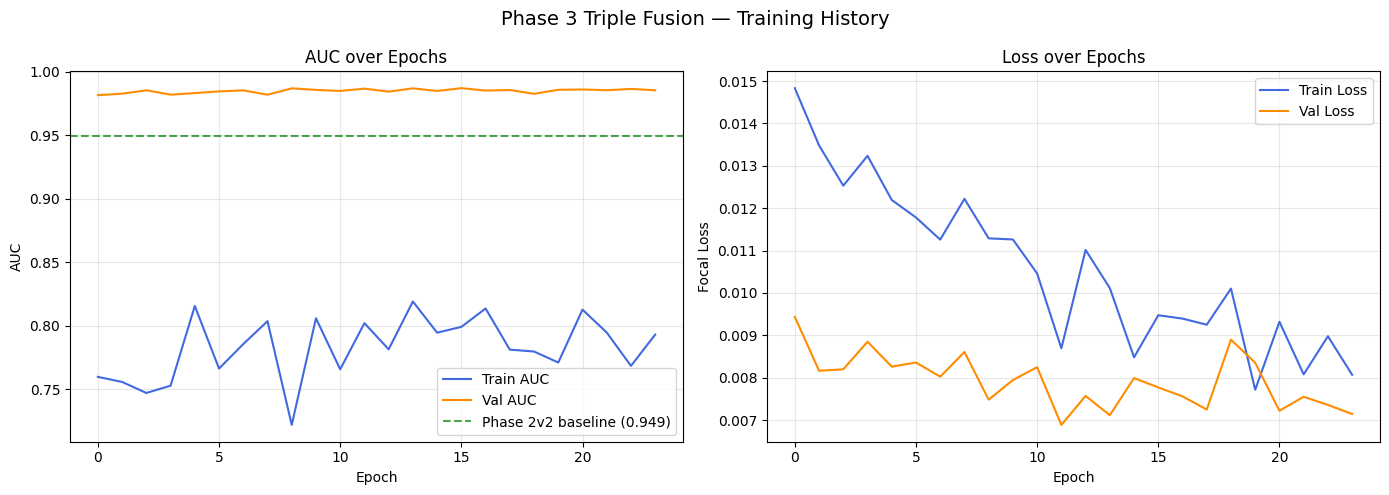

Saved training curves.


In [15]:
# --- CELL 14: Training Curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_auc'], label='Train AUC', color='royalblue')
axes[0].plot(history['val_auc'],   label='Val AUC',   color='darkorange')
axes[0].axhline(0.949, ls='--', color='green', alpha=0.7, label='Phase 2v2 baseline (0.949)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('AUC')
axes[0].set_title('AUC over Epochs'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_loss'], label='Train Loss', color='royalblue')
axes[1].plot(history['val_loss'],   label='Val Loss',   color='darkorange')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Focal Loss')
axes[1].set_title('Loss over Epochs'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Phase 3 Triple Fusion — Training History', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'p3_training_curves.png'), dpi=150)
plt.show()
print('Saved training curves.')

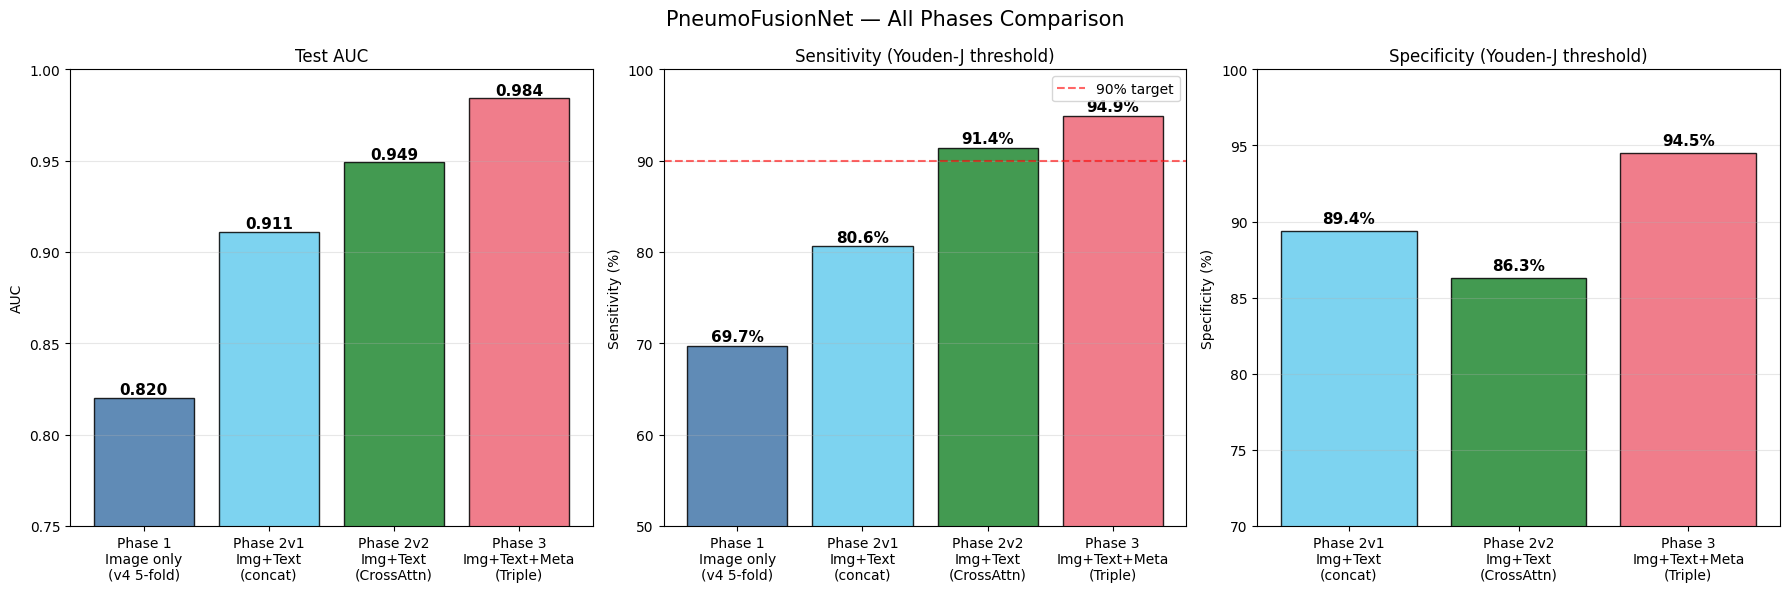

Saved all-phases comparison.


In [16]:
# --- CELL 15: All-Phases Comparison Chart ---

phases = [
    {'name': 'Phase 1\nImage only\n(v4 5-fold)', 'auc': 0.820, 'sens': 69.7, 'spec': None},
    {'name': 'Phase 2v1\nImg+Text\n(concat)',     'auc': 0.911, 'sens': 80.6, 'spec': 89.4},
    {'name': 'Phase 2v2\nImg+Text\n(CrossAttn)',  'auc': 0.949, 'sens': 91.4, 'spec': 86.3},
    {'name': 'Phase 3\nImg+Text+Meta\n(Triple)',  'auc': round(test_auc, 4),
                                                  'sens': round(s_y*100, 1),
                                                  'spec': round(sp_y*100, 1)},
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
names = [p['name'] for p in phases]
colors = ['#4477AA', '#66CCEE', '#228833', '#EE6677']

# AUC
axes[0].bar(names, [p['auc'] for p in phases], color=colors, edgecolor='black', alpha=0.85)
axes[0].set_ylim(0.75, 1.0)
axes[0].set_ylabel('AUC'); axes[0].set_title('Test AUC')
axes[0].grid(axis='y', alpha=0.3)
for i,p in enumerate(phases):
    axes[0].text(i, p['auc']+0.002, f"{p['auc']:.3f}", ha='center', fontsize=11, fontweight='bold')

# Sensitivity
sens_vals = [p['sens'] for p in phases]
axes[1].bar(names, sens_vals, color=colors, edgecolor='black', alpha=0.85)
axes[1].set_ylim(50, 100)
axes[1].axhline(90, ls='--', color='red', alpha=0.6, label='90% target')
axes[1].set_ylabel('Sensitivity (%)'); axes[1].set_title('Sensitivity (Youden-J threshold)')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
for i,v in enumerate(sens_vals):
    axes[1].text(i, v+0.5, f"{v:.1f}%", ha='center', fontsize=11, fontweight='bold')

# Specificity
spec_vals = [p['spec'] if p['spec'] is not None else 0 for p in phases]
axes[2].bar(names[1:], spec_vals[1:], color=colors[1:], edgecolor='black', alpha=0.85)
axes[2].set_ylim(70, 100)
axes[2].set_ylabel('Specificity (%)'); axes[2].set_title('Specificity (Youden-J threshold)')
axes[2].grid(axis='y', alpha=0.3)
for i,v in enumerate(spec_vals[1:]):
    axes[2].text(i, v+0.5, f"{v:.1f}%", ha='center', fontsize=11, fontweight='bold')

plt.suptitle('PneumoFusionNet — All Phases Comparison', fontsize=15)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'p3_all_phases_comparison.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved all-phases comparison.')

Computing clinical feature importances via permutation...
Baseline AUC: 0.9841


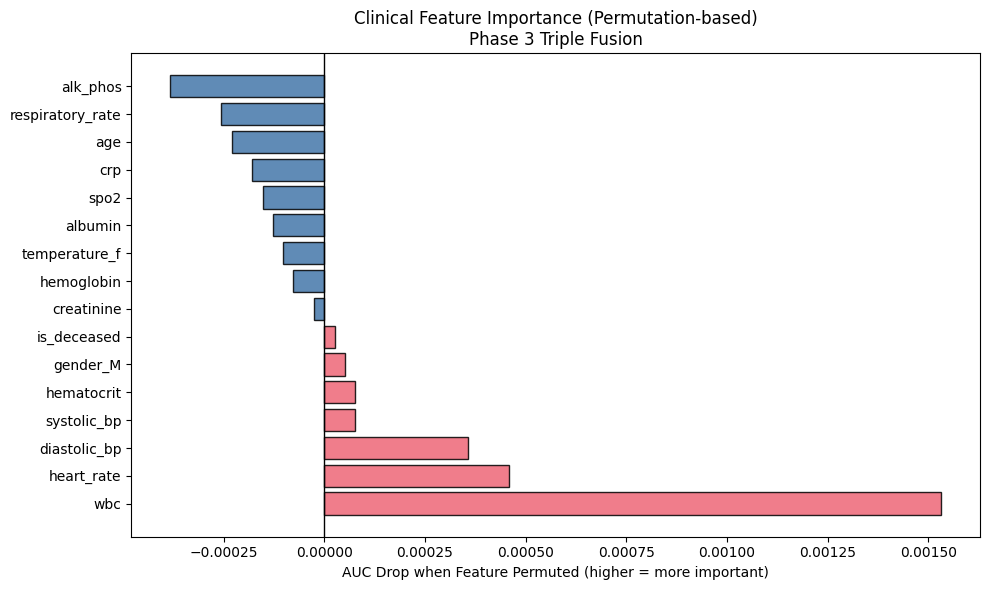


Feature Importances:
  wbc                 : +0.0015
  heart_rate          : +0.0005
  diastolic_bp        : +0.0004
  systolic_bp         : +0.0001
  hematocrit          : +0.0001
  gender_M            : +0.0001
  is_deceased         : +0.0000
  creatinine          : -0.0000
  hemoglobin          : -0.0001
  temperature_f       : -0.0001
  albumin             : -0.0001
  spo2                : -0.0002
  crp                 : -0.0002
  age                 : -0.0002
  respiratory_rate    : -0.0003
  alk_phos            : -0.0004


In [17]:
# --- CELL 16: Clinical Feature Importance (Permutation-based) ---
print('Computing clinical feature importances via permutation...')

fusion_model.eval(); image_encoder.eval(); text_encoder.eval(); meta_encoder.eval()

# Baseline AUC
_,_,baseline_auc,_,_ = eval_epoch(
    fusion_model, image_encoder, text_encoder, meta_encoder,
    test_loader, criterion_focal, DEVICE)
print(f'Baseline AUC: {baseline_auc:.4f}')

feature_importances = {}
for feat_idx, feat_name in enumerate(CLINICAL_FEATURES):
    # Evaluate with this feature permuted
    all_probs_perm, all_labels_perm = [], []
    with torch.no_grad():
        for imgs,ids,masks,meta,labels in test_loader:
            imgs   = imgs.to(DEVICE)
            ids    = ids.to(DEVICE)
            masks  = masks.to(DEVICE)
            meta   = meta.clone().to(DEVICE)
            labels = labels.to(DEVICE)

            # Permute this specific feature
            perm_idx = torch.randperm(meta.size(0))
            meta[:, feat_idx] = meta[perm_idx, feat_idx]

            img_f  = image_encoder(imgs)
            txt_t  = text_encoder(ids, masks)
            meta_f = meta_encoder(meta)
            logits = fusion_model(img_f, txt_t, meta_f)
            probs  = F.softmax(logits, dim=1)[:,1].cpu().numpy()
            all_probs_perm.extend(probs)
            all_labels_perm.extend(labels.cpu().tolist())

    perm_auc = roc_auc_score(all_labels_perm, all_probs_perm)
    feature_importances[feat_name] = baseline_auc - perm_auc

# Sort and plot
sorted_feats = sorted(feature_importances.items(), key=lambda x: x[1], reverse=True)
feat_names = [f[0] for f in sorted_feats]
feat_imps  = [f[1] for f in sorted_feats]

plt.figure(figsize=(10, 6))
colors_bar = ['#EE6677' if v > 0 else '#4477AA' for v in feat_imps]
plt.barh(feat_names, feat_imps, color=colors_bar, edgecolor='black', alpha=0.85)
plt.axvline(0, color='black', lw=1)
plt.xlabel('AUC Drop when Feature Permuted (higher = more important)')
plt.title('Clinical Feature Importance (Permutation-based)\nPhase 3 Triple Fusion')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'p3_feature_importance.png'), dpi=150)
plt.show()
print('\nFeature Importances:')
for name, imp in sorted_feats:
    print(f'  {name:20s}: {imp:+.4f}')

In [18]:
# --- CELL 17: Save Results JSON & Config ---

results = {
    'phase': 3,
    'description': 'Triple Fusion: Image + Text + Clinical Metadata',
    'architecture': {
        'image_encoder':  'DenseNet121+CBAM (frozen from Phase 1.1v4 Fold 2)',
        'text_encoder':   'Bio_ClinicalBERT (last 2 layers unfrozen)',
        'meta_encoder':   f'MLP({N_CLINICAL_FEATURES}->128->128->{META_OUT_DIM})',
        'fusion':         'CrossAttention(img queries text) + concat meta + MLP classifier',
        'fused_dim':      IMG_FEAT_DIM + ATTN_DIM + META_OUT_DIM,
        'clinical_feats': CLINICAL_FEATURES,
        'p2v2_weights_loaded': os.path.exists(P2V2_CKPT)
    },
    'training': {
        'n_train': len(train_df), 'n_val': len(val_df), 'n_test': len(test_df),
        'batch_size': BATCH_SIZE, 'epochs_run': len(history['val_auc']),
        'lr_fusion': LR_FUSION, 'lr_bert': LR_BERT, 'lr_meta': LR_META,
        'focal_gamma': FOCAL_GAMMA, 'mixup_alpha': MIXUP_ALPHA
    },
    'results': {
        'test_auc':           round(test_auc, 4),
        'best_val_auc':       round(best_auc, 4),
        'default_acc':        round(ac_d, 4),
        'default_sensitivity': round(s_d, 4),
        'default_specificity': round(sp_d, 4),
        'youden_threshold':   round(thresh_youden, 4),
        'youden_acc':         round(ac_y, 4),
        'youden_sensitivity': round(s_y, 4),
        'youden_specificity': round(sp_y, 4),
        'clinical_threshold': round(thresh_clinical, 4),
        'clinical_acc':       round(ac_c, 4),
        'clinical_sensitivity': round(s_c, 4),
        'clinical_specificity': round(sp_c, 4),
        'n_test': len(test_labels)
    },
    'feature_importances': {k: round(v, 4) for k, v in feature_importances.items()},
    'comparison_vs_p2v2': {
        'p2v2_auc':      0.949,
        'p3_auc':        round(test_auc, 4),
        'auc_delta':     round(test_auc - 0.949, 4),
        'p2v2_sens':     0.914,
        'p3_sens':       round(s_y, 4),
        'sens_delta':    round(s_y - 0.914, 4)
    }
}

out_path = os.path.join(SAVE_DIR, 'phase3_results.json')
with open(out_path, 'w') as f:
    json.dump(results, f, indent=2)

print('='*60)
print('PHASE 3 TRIPLE FUSION — FINAL RESULTS')
print('='*60)
print(f'Test AUC         : {test_auc:.4f}')
print(f'Sensitivity (Y-J): {s_y*100:.1f}%')
print(f'Specificity (Y-J): {sp_y*100:.1f}%')
print(f'Accuracy    (Y-J): {ac_y*100:.1f}%')
print(f'\nvs Phase 2v2:')
print(f'  AUC delta  : {test_auc-0.949:+.4f}')
print(f'  Sens delta : {s_y-0.914:+.3f}')
print(f'\nResults saved to: {out_path}')

PHASE 3 TRIPLE FUSION — FINAL RESULTS
Test AUC         : 0.9841
Sensitivity (Y-J): 94.9%
Specificity (Y-J): 94.5%
Accuracy    (Y-J): 94.7%

vs Phase 2v2:
  AUC delta  : +0.0351
  Sens delta : +0.035

Results saved to: c:\\2026\\PneumoFusionNet\\mimic\\1000_dataset\outputs\Phase_3_triple_fusion\phase3_results.json
